In [2]:
# SESSION 7 - Data Cleaning (Part 2: Outliers & Data Types)


# 1. Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating' column using the IQR method and print the indices of the detected outliers.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

zomato_data = pd.read_csv("zomato_ratings.csv")

Q1 = zomato_data["rating"].quantile(0.25)
Q3 = zomato_data["rating"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = zomato_data[
    (zomato_data["rating"] < lower_limit) |
    (zomato_data["rating"] > upper_limit)
]

print("Outlier Indices:")
print(outliers.index)



Outlier Indices:
RangeIndex(start=0, stop=0, step=1)


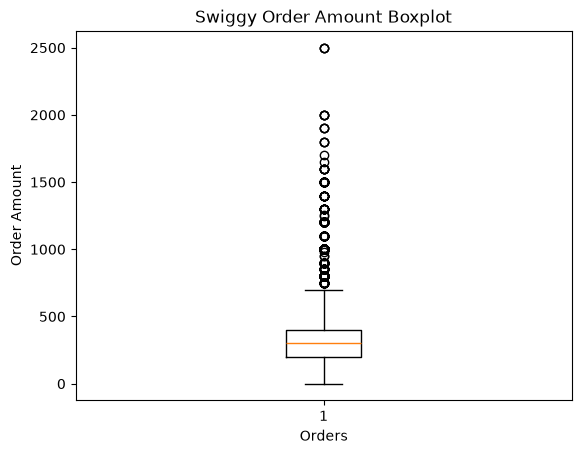

In [5]:

# 2. Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, and visually identify any outliers present.

swiggy_data = pd.read_csv("swiggy_orders.csv")

plt.boxplot(swiggy_data["order_amount"].dropna())

plt.xlabel("Orders")
plt.ylabel("Order Amount")
plt.title("Swiggy Order Amount Boxplot")

plt.show()



In [8]:

# 3. Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap all values above the 95th percentile and below the 5th percentile, then display the updated column statistics.

paytm_data = pd.read_csv("paytm_transactions.csv")

lower_limit = paytm_data["transaction_amount"].quantile(0.05)
upper_limit = paytm_data["transaction_amount"].quantile(0.95)

paytm_data["transaction_amount"] = paytm_data[
    "transaction_amount"
].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("Updated Transaction Amount Statistics:")
print(paytm_data["transaction_amount"].describe())



Updated Transaction Amount Statistics:
count    15.000000
mean      5.585333
std       3.373650
min       1.480000
25%       2.700000
50%       5.000000
75%       8.000000
max      11.200000
Name: transaction_amount, dtype: float64


In [12]:
# 4. You have a DataFrame of Flipkart product prices stored as strings with currency symbols (e.g., '₹1,299'). Convert this column to numeric type using pandas, ensuring all non-numeric characters are removed.

flipkart_data = pd.read_csv("flipkart_products.csv")

flipkart_data["price"] = pd.to_numeric(
    flipkart_data["price"],
    errors="coerce"
)

print("Converted Price Column:")
print(flipkart_data["price"])

print("\nPrice Data Type:")
print(flipkart_data["price"].dtype)

Converted Price Column:
0       2216
1        379
2       1919
3       1499
4       2050
        ... 
1634     719
1635     549
1636     569
1637     459
1638     439
Name: price, Length: 1639, dtype: int64

Price Data Type:
int64


In [14]:

# 5. Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of boolean, string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 'yes' as True, and everything else as False.

spotify_data = pd.read_csv("spotify_users.csv")

spotify_data["is_premium"] = spotify_data["is_premium"].apply(
    lambda x: True
    if str(x).lower() in ["true", "1", "yes"]
    else False
)

print("Updated is_premium Column:")
print(spotify_data["is_premium"])

print("\nData Type:")
print(spotify_data["is_premium"].dtype)

Updated is_premium Column:
0     True
1     True
2     True
3    False
4    False
5    False
Name: is_premium, dtype: bool

Data Type:
bool
